In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Load the merged dataset
df = pd.read_csv('/Users/yaswanthkanagarla/Desktop/Master_Thesis/BD_code/Battery_Diagnostics_Thesis/scripts/merged_eis_capacity_state_IX_norm.csv')

state_map = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5, 'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9}
df['state'] = df['state'].map(state_map)
train_groups = [(25, 6), (25, 7),(25, 8), (25, 5), (25, 3), (25, 4), (35, 1),(25, 2), (45, 2)]
#val_groups   = [(25, 2), (45, 2)]                 # validation cell(s)
test_groups  = [(25, 1), (35, 2), (45, 1),]         # final test cell(s)
def mask_from_groups(df, groups):
    groups = set(groups)
    return df.apply(lambda r: (r["T_C"], r["cell"]) in groups, axis=1)

train_mask = mask_from_groups(df, train_groups)
#val_mask   = mask_from_groups(df, val_groups)
test_mask  = mask_from_groups(df, test_groups)

train_df = df[train_mask].copy()
#val_df   = df[val_mask].copy()
test_df  = df[test_mask].copy()

print("Train:", train_df.shape, "Groups:", sorted(set(zip(train_df.T_C, train_df.cell))))
#print("Val  :", val_df.shape,   "Groups:", sorted(set(zip(val_df.T_C, val_df.cell))))
print("Test :", test_df.shape,  "Groups:", sorted(set(zip(test_df.T_C, test_df.cell))))

Train: (1770, 31) Groups: [(25, 2), (25, 3), (25, 4), (25, 5), (25, 6), (25, 7), (25, 8), (35, 1), (45, 2)]
Test : (966, 31) Groups: [(25, 1), (35, 2), (45, 1)]


In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

features = ["R_s_rel","R_sei_rel","Zmag_0.1Hz_rel","C_dl_log","tail_slope","Zmag_1000Hz_rel","T_C","R_ct_rel"]
#"tail_angle_deg","Phase_1000Hz","Phase_100Hz","Zmag_10Hz_rel","f_peak_main", "Zmag_100Hz_rel","Phase_10Hz","Phase_0.1Hz"
X_train, y_train = train_df[features], train_df["SOH"]
#X_val,   y_val   = val_df[features],   val_df["SOH"]
X_test,  y_test  = test_df[features],  test_df["SOH"]

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred)
    }

print("Train:", metrics(y_train, rf.predict(X_train)))
#print("Val  :", metrics(y_val,   rf.predict(X_val)))
print("Test :", metrics(y_test,  rf.predict(X_test)))


Train: {'R2': 0.9990597475336556, 'MAE': 0.002681788574422235, 'RMSE': np.float64(0.0054544244323763424), 'MSE': 2.975074588850398e-05}
Test : {'R2': 0.8649292516497503, 'MAE': 0.054164297852182824, 'RMSE': np.float64(0.06672996199041223), 'MSE': 0.004452887827241861}


In [55]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt",
    min_samples_leaf=1
)

rf_base.fit(X_train, y_train)

print("Base RF")
print("Train:", metrics(y_train, rf_base.predict(X_train)))
#print("Val  :", metrics(y_val,   rf_base.predict(X_val)))
print("Test :", metrics(y_test,  rf_base.predict(X_test)))


Base RF
Train: {'R2': 0.9990392898820625, 'MAE': 0.0031248588803740253, 'RMSE': np.float64(0.0055134427699068895), 'MSE': 3.039805117703855e-05}
Test : {'R2': 0.8978849360052097, 'MAE': 0.04787249449973727, 'RMSE': np.float64(0.05802098954189947), 'MSE': 0.0033664352274212083}


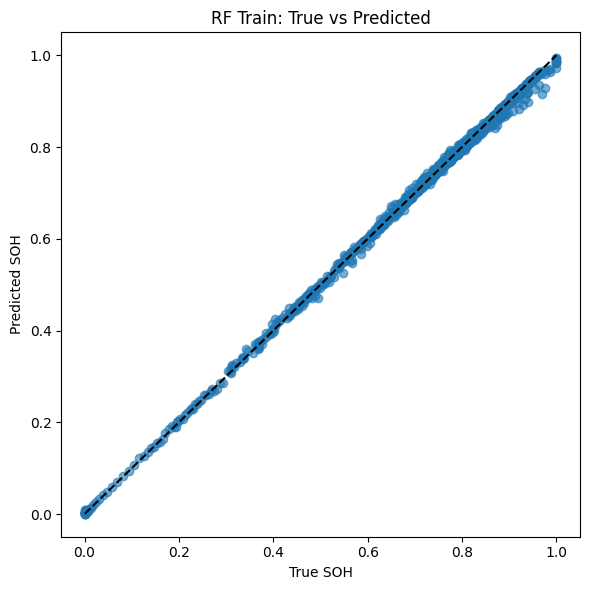

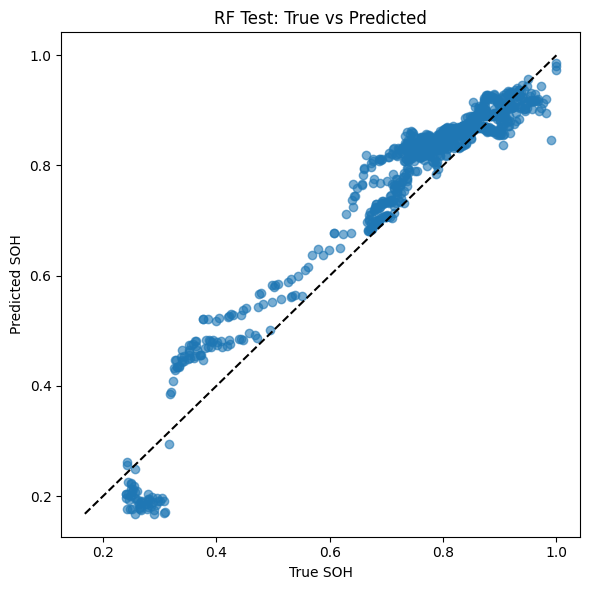

In [56]:
import matplotlib.pyplot as plt
import numpy as np

def true_vs_pred_plot(y_true, y_pred, title):
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())

    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([lo, hi], [lo, hi], "k--")
    plt.xlabel("True SOH")
    plt.ylabel("Predicted SOH")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Train
true_vs_pred_plot(y_train, rf_base.predict(X_train), "RF Train: True vs Predicted")

# Val
#true_vs_pred_plot(y_val, rf_base.predict(X_val), "RF Validation: True vs Predicted")

# Test
true_vs_pred_plot(y_test, rf_base.predict(X_test), "RF Test: True vs Predicted")


In [9]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

results = []
best_rmse = np.inf
best_model = None
best_params = None

for n_estimators in [300, 600, 1000]:
    for max_depth in [None, 8, 12, 16, 24]:
        for min_samples_leaf in [1, 2, 4, 8]:
            for max_features in ["sqrt", 0.5, 0.7, 1.0]:
                rf = RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    random_state=42,
                    n_jobs=-1
                )
                rf.fit(X_train, y_train)

                val_pred = rf.predict(X_val)
                rmse = float(np.sqrt(mean_squared_error(y_val, val_pred)))

                row = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_features": max_features,
                    "val_rmse": rmse
                }
                results.append(row)

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_model = rf
                    best_params = row

results_df = pd.DataFrame(results).sort_values("val_rmse")
print("Best params:", best_params)
print("Best Val RMSE:", best_rmse)
results_df.head(10)


NameError: name 'X_val' is not defined

In [ ]:
print("Tuned RF")
print("Train:", metrics(y_train, best_model.predict(X_train)))
print("Val  :", metrics(y_val,   best_model.predict(X_val)))
print("Test :", metrics(y_test,  best_model.predict(X_test)))


Tuned RF
Train: {'R2': 0.998728749847556, 'MAE': 0.0035527218765134894, 'RMSE': np.float64(0.0070337257703327405)}
Val  : {'R2': 0.7218999480876276, 'MAE': 0.03200733153234426, 'RMSE': np.float64(0.03768876177678645)}
Test : {'R2': 0.9009746076714163, 'MAE': 0.04877978817027685, 'RMSE': np.float64(0.057136483810158505)}


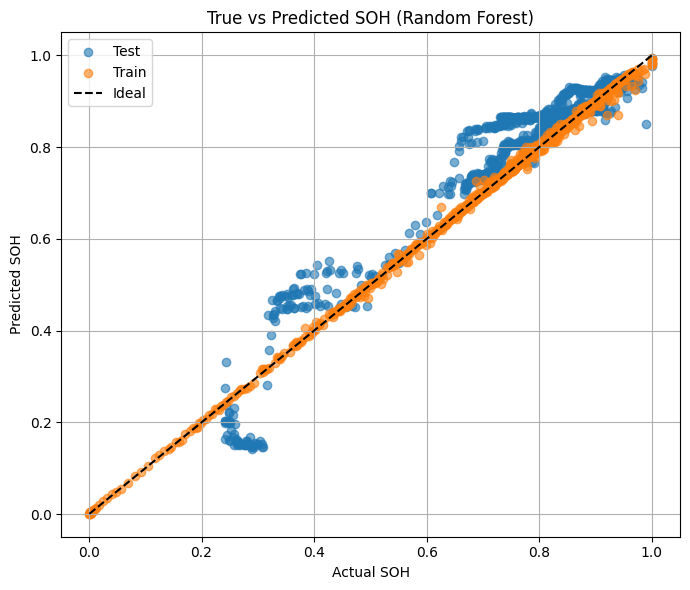

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred  = rf.predict(X_test)

# To Create plotting DataFrames
train_plot = pd.DataFrame({
    "SOH_true": y_train,
    "SOH_pred": y_train_pred,
    "set": "Train"
})

test_plot = pd.DataFrame({
    "SOH_true": y_test,
    "SOH_pred": y_test_pred,
    "set": "Test"
})

plot_df = pd.concat([train_plot, test_plot])

# Diagonal limits
min_val = min(plot_df["SOH_true"].min(), plot_df["SOH_pred"].min())
max_val = max(plot_df["SOH_true"].max(), plot_df["SOH_pred"].max())

# Plot
plt.figure(figsize=(7,6))
for s, df_s in plot_df.groupby("set"):
    plt.scatter(
        df_s["SOH_true"],
        df_s["SOH_pred"],
        label=s,
        alpha=0.6
    )

plt.plot([min_val, max_val], [min_val, max_val], "k--", label="Ideal")
plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("True vs Predicted SOH (Random Forest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Num features in X_train: 8
Num importances: 8
           feature  importance
2   Zmag_0.1Hz_rel    0.618173
5  Zmag_1000Hz_rel    0.242701
0          R_s_rel    0.056460
3         C_dl_log    0.043284
6              T_C    0.015744
7         R_ct_rel    0.010630
1        R_sei_rel    0.008790
4       tail_slope    0.004219


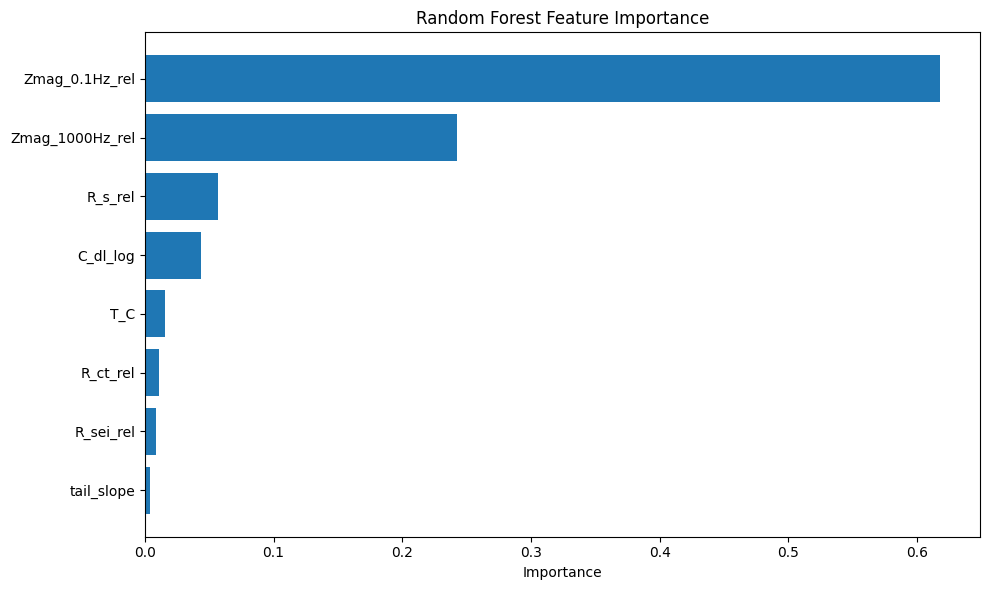

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_cols = list(X_train.columns)

importances = rf.feature_importances_

print("Num features in X_train:", len(feature_cols))
print("Num importances:", len(importances))

feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10,6))
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

tree_preds = np.array([
    tree.predict(X_test)
    for tree in rf.estimators_
])  # shape: (n_trees, n_samples)


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Decisio

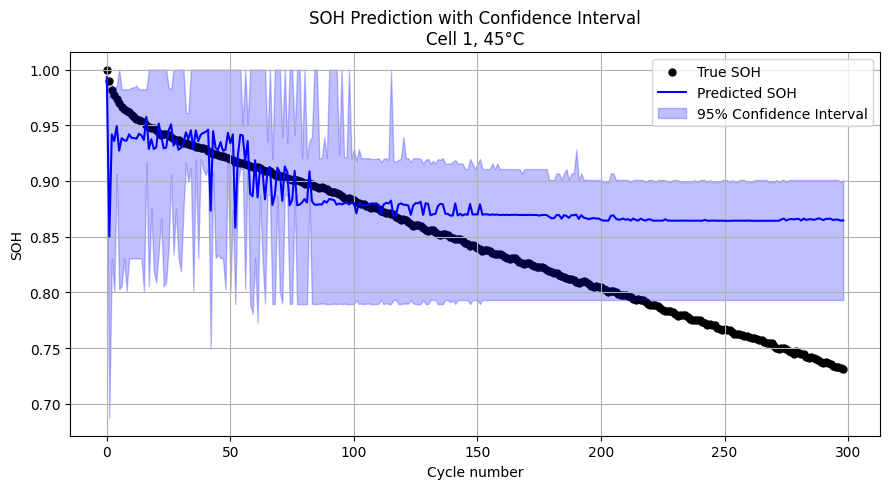

In [63]:
y_pred_mean = tree_preds.mean(axis=0)

lower = np.percentile(tree_preds, 2.5, axis=0)
upper = np.percentile(tree_preds, 97.5, axis=0)
plot_df = test_df.copy()
plot_df = plot_df.reset_index(drop=True)

plot_df["SOH_pred"] = y_pred_mean
plot_df["SOH_lower"] = lower
plot_df["SOH_upper"] = upper




import matplotlib.pyplot as plt

cell_id = 1
temp = 45

df_plot = plot_df[
    (plot_df["cell"] == cell_id) &
    (plot_df["T_C"] == temp)
].sort_values("cycle")

plt.figure(figsize=(9, 5))

# True SOH
plt.scatter(
    df_plot["cycle"],
    df_plot["SOH"],
    label="True SOH",
    color="black",
    s=25
)

# Predicted SOH
plt.plot(
    df_plot["cycle"],
    df_plot["SOH_pred"],
    label="Predicted SOH",
    color="blue"
)

# Confidence band
plt.fill_between(
    df_plot["cycle"],
    df_plot["SOH_lower"],
    df_plot["SOH_upper"],
    color="blue",
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.xlabel("Cycle number")
plt.ylabel("SOH")
plt.title(f"SOH Prediction with Confidence Interval\nCell {cell_id}, {temp}°C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


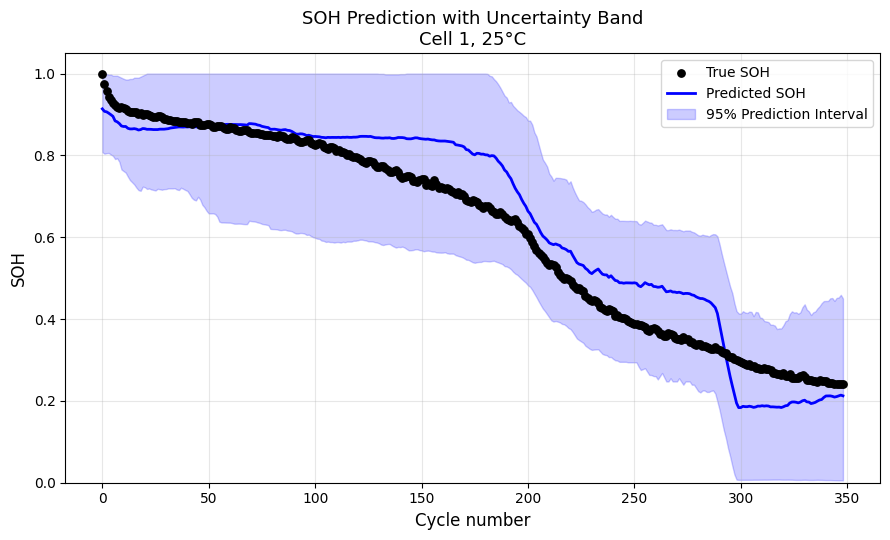

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mean prediction from all trees
y_pred_mean = tree_preds.mean(axis=0)

# Percentile band from tree distribution
lower = np.percentile(tree_preds, 2.5, axis=0)
upper = np.percentile(tree_preds, 97.5, axis=0)

# Create plotting dataframe
plot_df = test_df.copy().reset_index(drop=True)
plot_df["SOH_pred"] = y_pred_mean
plot_df["SOH_lower"] = lower
plot_df["SOH_upper"] = upper

# Selecting one cell and temperature
cell_id = 1
temp = 25

df_plot = plot_df[
    (plot_df["cell"] == cell_id) &
    (plot_df["T_C"] == temp)
].sort_values("cycle").copy()

# Clip values to physical SOH range
df_plot["SOH_pred"] = df_plot["SOH_pred"].clip(0, 1)
df_plot["SOH_lower"] = df_plot["SOH_lower"].clip(0, 1)
df_plot["SOH_upper"] = df_plot["SOH_upper"].clip(0, 1)

# Smooth prediction and interval for better visualization
window = 10  

df_plot["SOH_pred_smooth"] = df_plot["SOH_pred"].rolling(window=window, center=True, min_periods=1).mean()
df_plot["SOH_lower_smooth"] = df_plot["SOH_lower"].rolling(window=window, center=True, min_periods=1).mean()
df_plot["SOH_upper_smooth"] = df_plot["SOH_upper"].rolling(window=window, center=True, min_periods=1).mean()

# Plot
plt.figure(figsize=(9, 5.5))

# True SOH
plt.scatter(
    df_plot["cycle"],
    df_plot["SOH"],
    label="True SOH",
    color="black",
    s=28,
    zorder=3
)

# Predicted SOH
plt.plot(
    df_plot["cycle"],
    df_plot["SOH_pred_smooth"],
    label="Predicted SOH",
    color="blue",
    linewidth=2
)

# Uncertainty band
plt.fill_between(
    df_plot["cycle"],
    df_plot["SOH_lower_smooth"],
    df_plot["SOH_upper_smooth"],
    color="blue",
    alpha=0.20,
    label="95% Prediction Interval"
)

plt.xlabel("Cycle number", fontsize=12)
plt.ylabel("SOH", fontsize=12)
plt.title(f"SOH Prediction with Uncertainty Band\nCell {cell_id}, {temp}°C", fontsize=13)
plt.ylim(0, 1.05)
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:253: FutureWarning: In the future, passing feature_perturbation='interventional' without providing a background dataset will raise an error. Please provide a background dataset to continue using the interventional approach or set feature_perturbation='auto' to automatically switch approaches.
  warnings.warn(


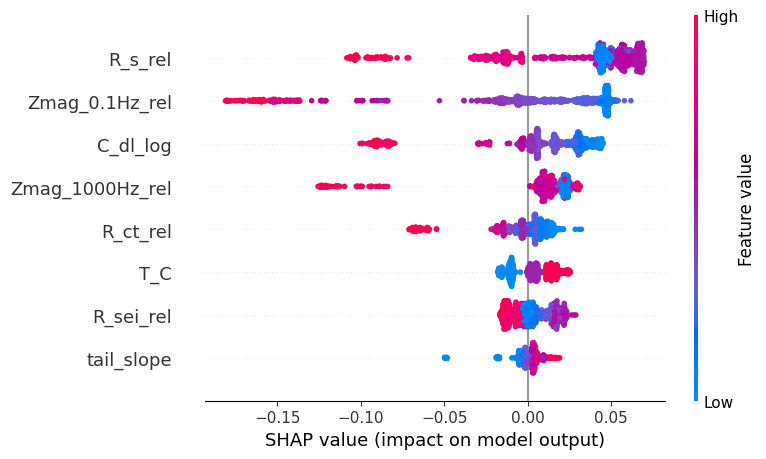

'# 1️⃣ Use SAME feature order as training\nX_shap = X_test.copy()\nX_shap = X_shap[X_train.columns]\n\n# 2️⃣ Apply SAME imputer used during training\nX_shap = pd.DataFrame(\n    imp.transform(X_shap),\n    columns=X_train.columns,\n    index=X_shap.index\n)\n\n# 3️⃣ Create explainer (interventional is safer)\nexplainer = shap.TreeExplainer(\n    rf_base,   # use your trained RF variable name\n    feature_perturbation="interventional"\n)\n\n# 4️⃣ Compute SHAP (disable strict additivity check)\nshap_values = explainer.shap_values(\n    X_shap,\n    check_additivity=False\n)\n\n# 5️⃣ Summary plots\nshap.summary_plot(shap_values, X_shap)\nshap.summary_plot(shap_values, X_shap, plot_type="bar")'

In [ ]:
import shap
import numpy as np
import pandas as pd


X_shap = X_test.copy()
X_shap = X_shap[X_train.columns]

explainer = shap.TreeExplainer(
    rf_base,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(
    X_shap,
    check_additivity=False
)

shap.summary_plot(shap_values, X_shap)


In [ ]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_imp = pd.Series(mean_abs_shap, index=X_shap.columns).sort_values(ascending=False)

shap_imp.head(25)


R_s_rel            0.049163
Zmag_0.1Hz_rel     0.045325
C_dl_log           0.028356
Zmag_1000Hz_rel    0.021372
R_ct_rel           0.012844
T_C                0.010368
R_sei_rel          0.010059
tail_slope         0.004794
dtype: float64

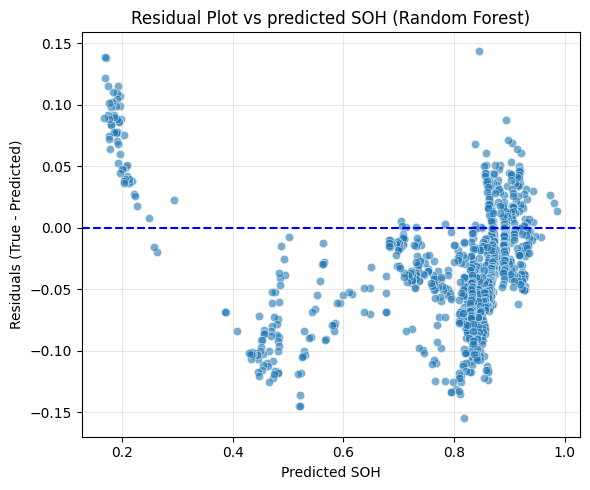

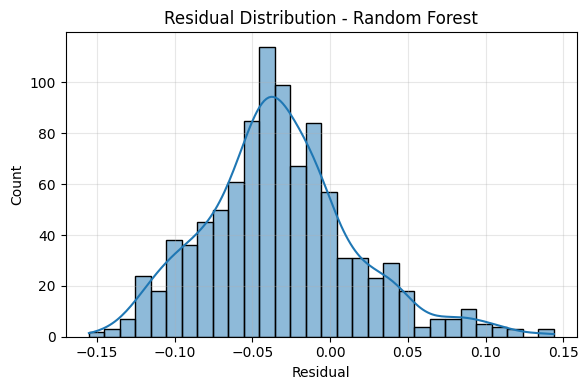

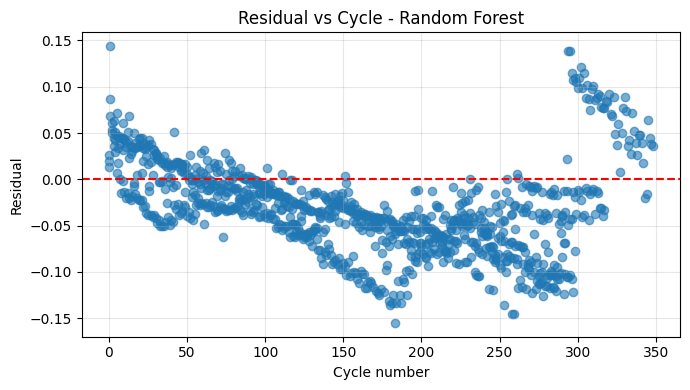

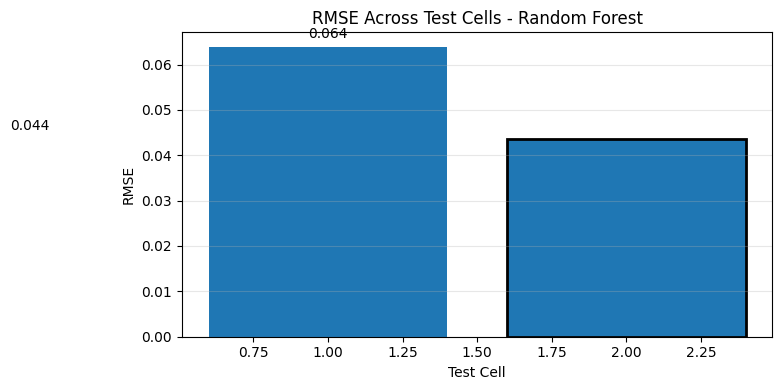

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# Reset indices to avoid mismatch
y_test = y_test.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Predict and compute residuals
y_pred = rf_base.predict(X_test)
residuals = y_test - y_pred

# 1. Residual vs Predicted Plot
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='blue', linestyle='--')
plt.xlabel("Predicted SOH")
plt.ylabel("Residuals (True - Predicted)")
plt.title("Residual Plot vs predicted SOH (Random Forest)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Residual Distribution Plot
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residual")
plt.title("Residual Distribution - Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Residual vs Cycle Plot
plt.figure(figsize=(7,4))
plt.scatter(test_df["cycle"], residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Cycle number")
plt.ylabel("Residual")
plt.title("Residual vs Cycle - Random Forest")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. RMSE per Test Cell
rmse_per_cell = {}

for cell in test_df["cell"].unique():
    mask = test_df["cell"] == cell
    y_true_cell = y_test[mask]
    y_pred_cell = y_pred[mask]
    rmse = np.sqrt(mean_squared_error(y_true_cell, y_pred_cell))
    rmse_per_cell[cell] = rmse

# Sort by RMSE for cleaner plotting
sorted_items = sorted(rmse_per_cell.items(), key=lambda x: x[1])
cells, rmse_values = zip(*sorted_items)

plt.figure(figsize=(8,4))
bars = plt.bar(cells, rmse_values)

# Highlight best cell (lowest RMSE)
best_idx = np.argmin(rmse_values)
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(2)

plt.xlabel("Test Cell")
plt.ylabel("RMSE")
plt.title("RMSE Across Test Cells - Random Forest")

for i, v in enumerate(rmse_values):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Random Forest test metrics:
{'R2': 0.8978849360052097, 'MAE': 0.04787249449973725, 'RMSE': np.float64(0.058020989541899465), 'MSE': 0.0033664352274212074}


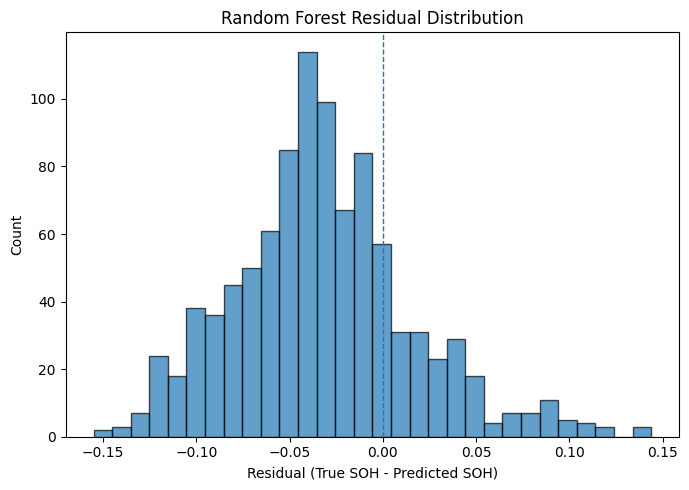

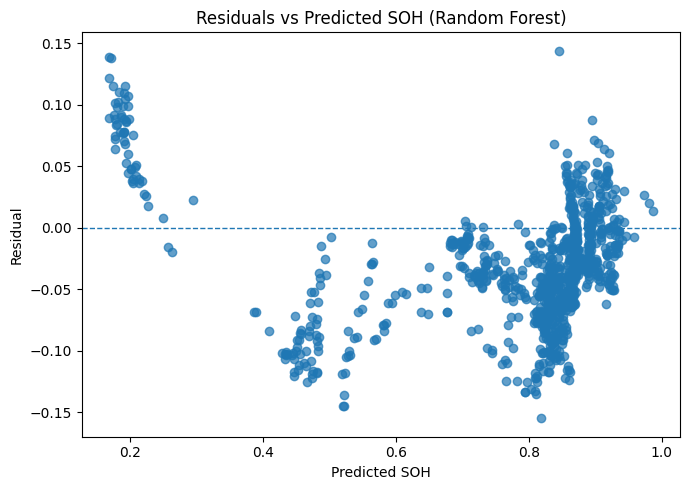

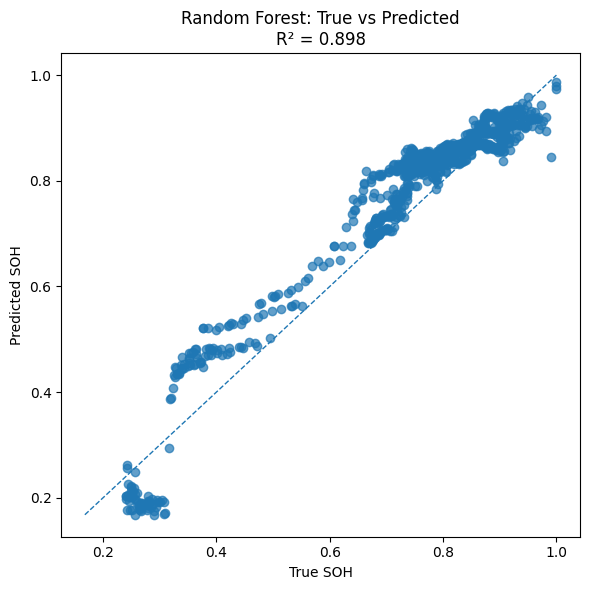


Bootstrap 95% Confidence Intervals for Random Forest:
R2: mean=0.8974, 95% CI=(0.8840, 0.9088)
MAE: mean=0.0479, 95% CI=(0.0458, 0.0499)
RMSE: mean=0.0580, 95% CI=(0.0557, 0.0601)


/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/yaswanthkanagarla/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Decisio

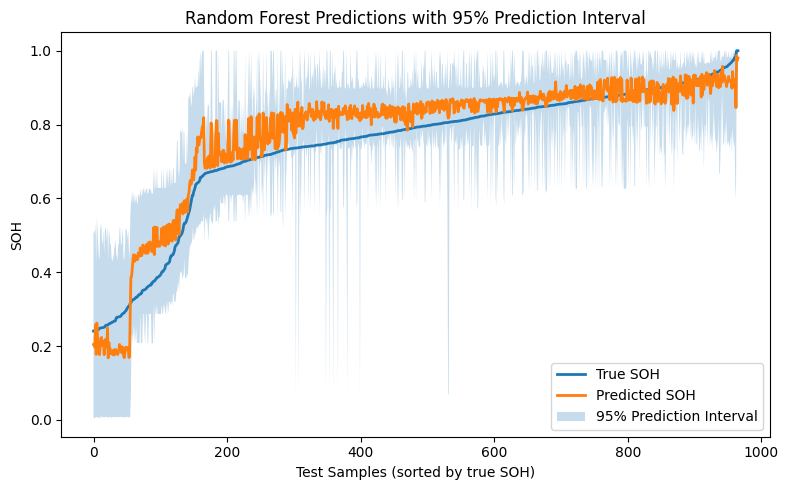

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) RF Predictions + Basic metrics
rf_pred = rf_base.predict(X_test)

def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
    }

print("Random Forest test metrics:")
print(regression_metrics(y_test, rf_pred))

# 2) Residuals
residuals = y_test - rf_pred

# Plot A: Residual histogram
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30, edgecolor="black", alpha=0.7)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Residual (True SOH - Predicted SOH)")
plt.ylabel("Count")
plt.title("Random Forest Residual Distribution")
plt.tight_layout()
plt.show()

# Plot B: Residuals vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(rf_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Predicted SOH")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted SOH (Random Forest)")
plt.tight_layout()
plt.show()

# Plot C: True vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.7)

min_val = min(np.min(y_test), np.min(rf_pred))
max_val = max(np.max(y_test), np.max(rf_pred))

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)
plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title(f"Random Forest: True vs Predicted\nR² = {r2_score(y_test, rf_pred):.3f}")
plt.tight_layout()
plt.show()

# 3) Bootstrap confidence interval for metrics
def bootstrap_metric_ci(y_true, y_pred, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    r2_list, mae_list, rmse_list = [], [], []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt = y_true[idx]
        yp = y_pred[idx]

        r2_list.append(r2_score(yt, yp))
        mae_list.append(mean_absolute_error(yt, yp))
        rmse_list.append(np.sqrt(mean_squared_error(yt, yp)))

    def ci(arr):
        return np.mean(arr), np.percentile(arr, 2.5), np.percentile(arr, 97.5)

    return {
        "R2": ci(r2_list),
        "MAE": ci(mae_list),
        "RMSE": ci(rmse_list),
    }

ci_results = bootstrap_metric_ci(y_test, rf_pred, n_boot=2000)

print("\nBootstrap 95% Confidence Intervals for Random Forest:")
for metric, (mean_val, low, high) in ci_results.items():
    print(f"{metric}: mean={mean_val:.4f}, 95% CI=({low:.4f}, {high:.4f})")

# 4) Pointwise prediction interval using tree predictions
#    (better for RF than bootstrap-shuffling predictions)
tree_preds = np.array([tree.predict(X_test) for tree in rf_base.estimators_])

pred_mean = np.mean(tree_preds, axis=0)
pred_low = np.percentile(tree_preds, 2.5, axis=0)
pred_high = np.percentile(tree_preds, 97.5, axis=0)

# Sort by true SOH for cleaner plotting
order = np.argsort(np.asarray(y_test))

y_test_sorted = np.asarray(y_test)[order]
pred_mean_sorted = pred_mean[order]
pred_low_sorted = pred_low[order]
pred_high_sorted = pred_high[order]

plt.figure(figsize=(8,5))
plt.plot(y_test_sorted, label="True SOH", linewidth=2)
plt.plot(pred_mean_sorted, label="Predicted SOH", linewidth=2)
plt.fill_between(
    np.arange(len(y_test_sorted)),
    pred_low_sorted,
    pred_high_sorted,
    alpha=0.25,
    label="95% Prediction Interval"
)

plt.xlabel("Test Samples (sorted by true SOH)")
plt.ylabel("SOH")
plt.title("Random Forest Predictions with 95% Prediction Interval")
plt.legend()
plt.tight_layout()
plt.show()